# Run trained PRNet + view predictions
Loads a checkpoint (`runs/last.pt` by default), runs sliding-window inference on eval samples, shows image / GT / pred / mismatch.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from monai.data import Dataset, DataLoader
from monai.inferers import sliding_window_inference

from dataset import NUM_CLASSES, CROP, class_names, list_pairs, eval_transforms
from model import PRNet

CKPT = os.path.join('runs', 'last.pt')   # or runs/<run-name>/best.pt
SPLIT = 'test'
N = 6

device = 'cuda' if torch.cuda.is_available() else 'cpu'
names = class_names()
cmap = ListedColormap(plt.cm.tab10(np.arange(NUM_CLASSES)))
device

'cuda'

In [2]:
model = PRNet(in_channels=3, num_classes=NUM_CLASSES, input_size=CROP).to(device)
ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"{CKPT}: epoch {ckpt.get('epoch')}, val_dice {ckpt.get('val_dice')}, run {ckpt.get('run_name')}")

runs\last.pt: epoch 1, val_dice 0.30324238538742065, run prnet-20260907-020405


GT: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)', 'Pulp', 'Apical Periodontitis (AP)'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)', 'Pulp']


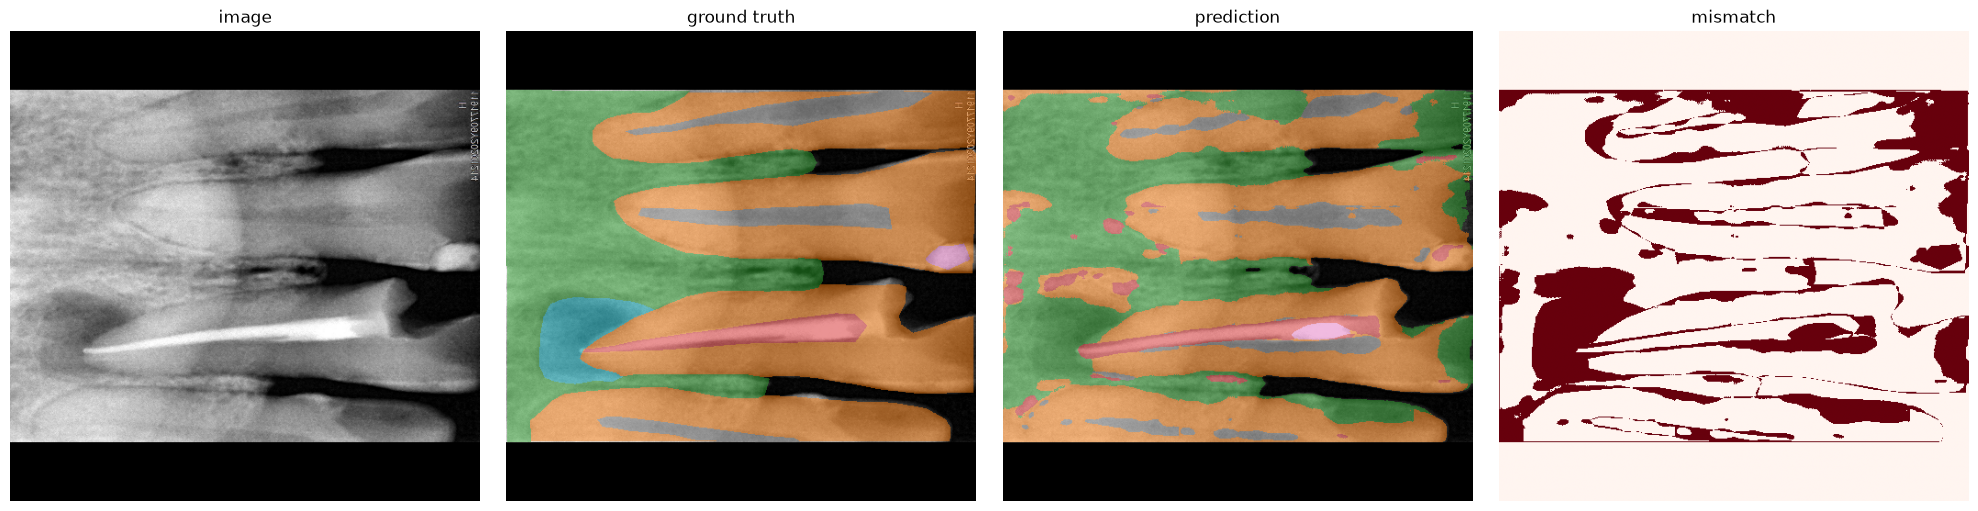

GT: ['Tooth', 'Alveolar Bone (AB)', 'Pulp'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Denture Crown (DC)', 'Dental Fillings (DF)', 'Pulp']


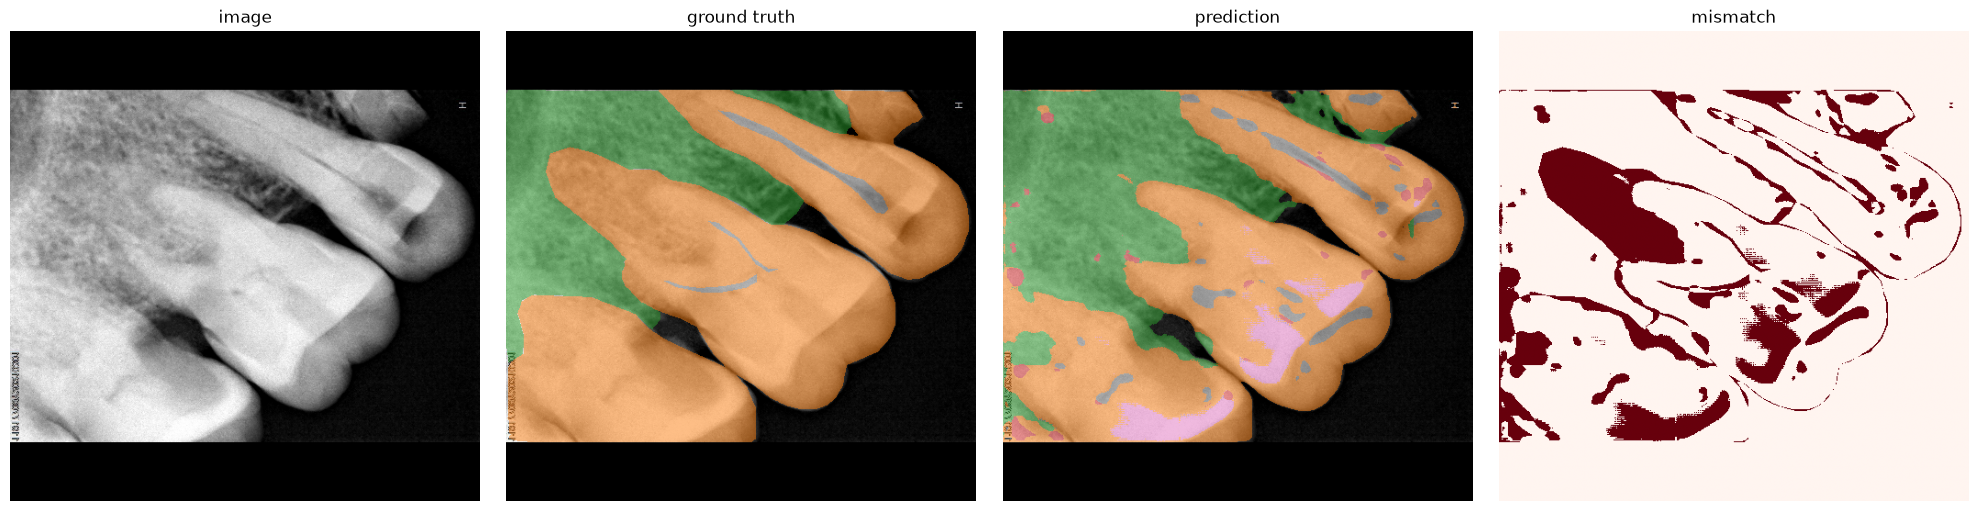

GT: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Dental Fillings (DF)', 'Pulp'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Denture Crown (DC)', 'Dental Fillings (DF)', 'Pulp']


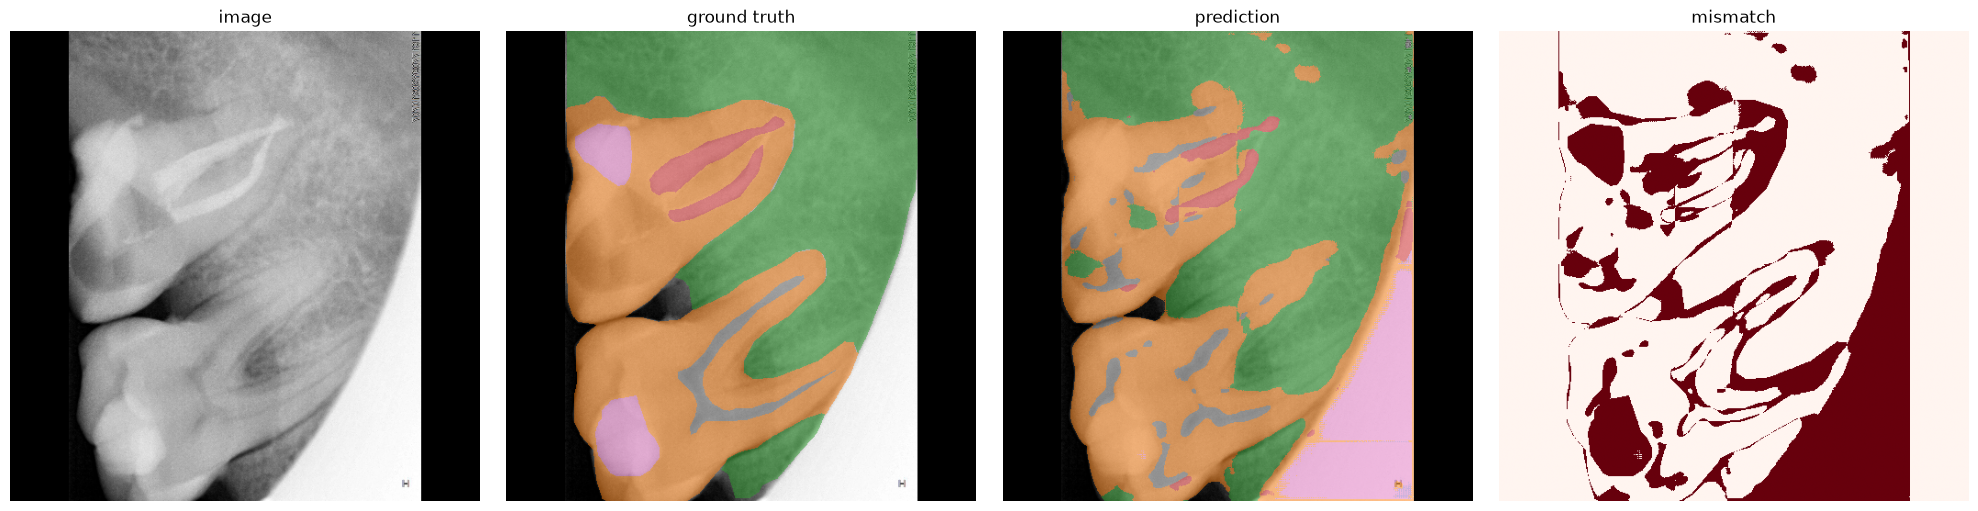

GT: ['Tooth', 'Alveolar Bone (AB)', 'Pulp'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Denture Crown (DC)', 'Dental Fillings (DF)', 'Pulp']


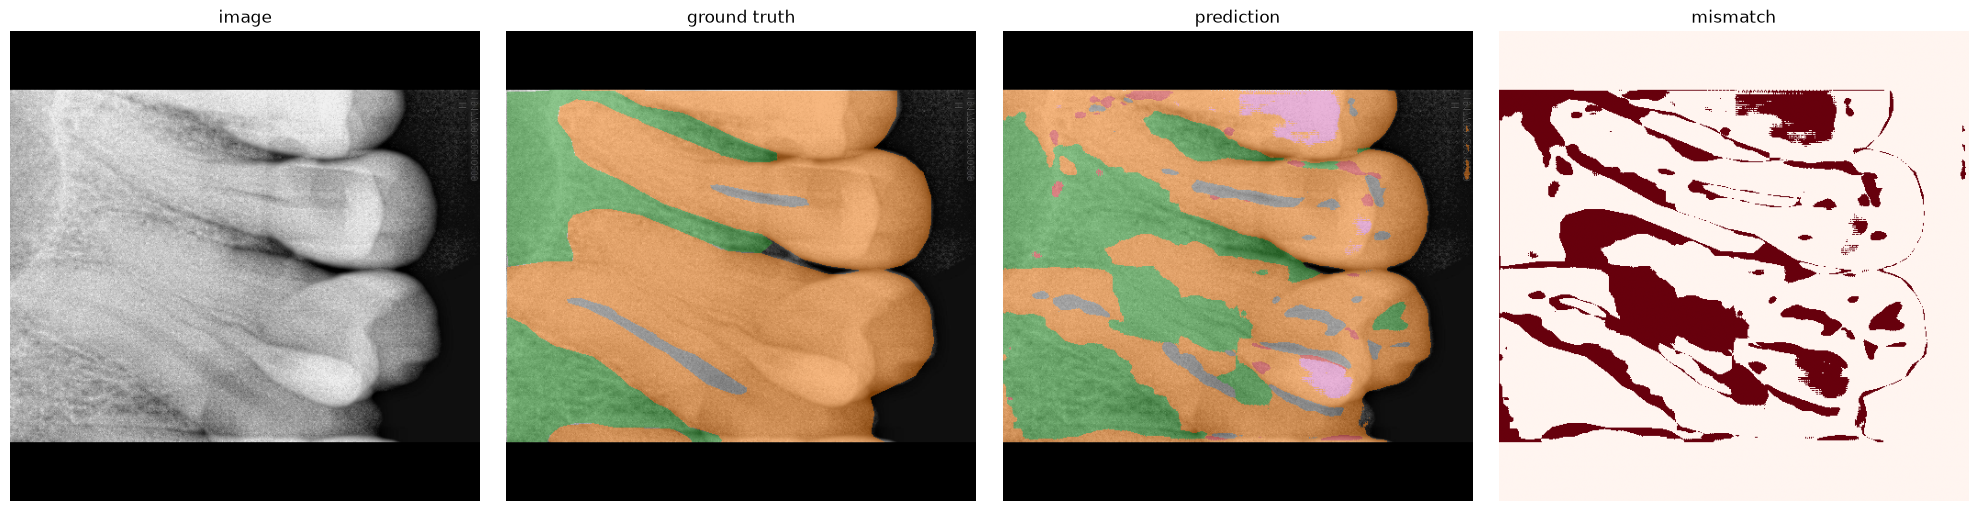

GT: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Pulp'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Denture Crown (DC)', 'Dental Fillings (DF)', 'Pulp']


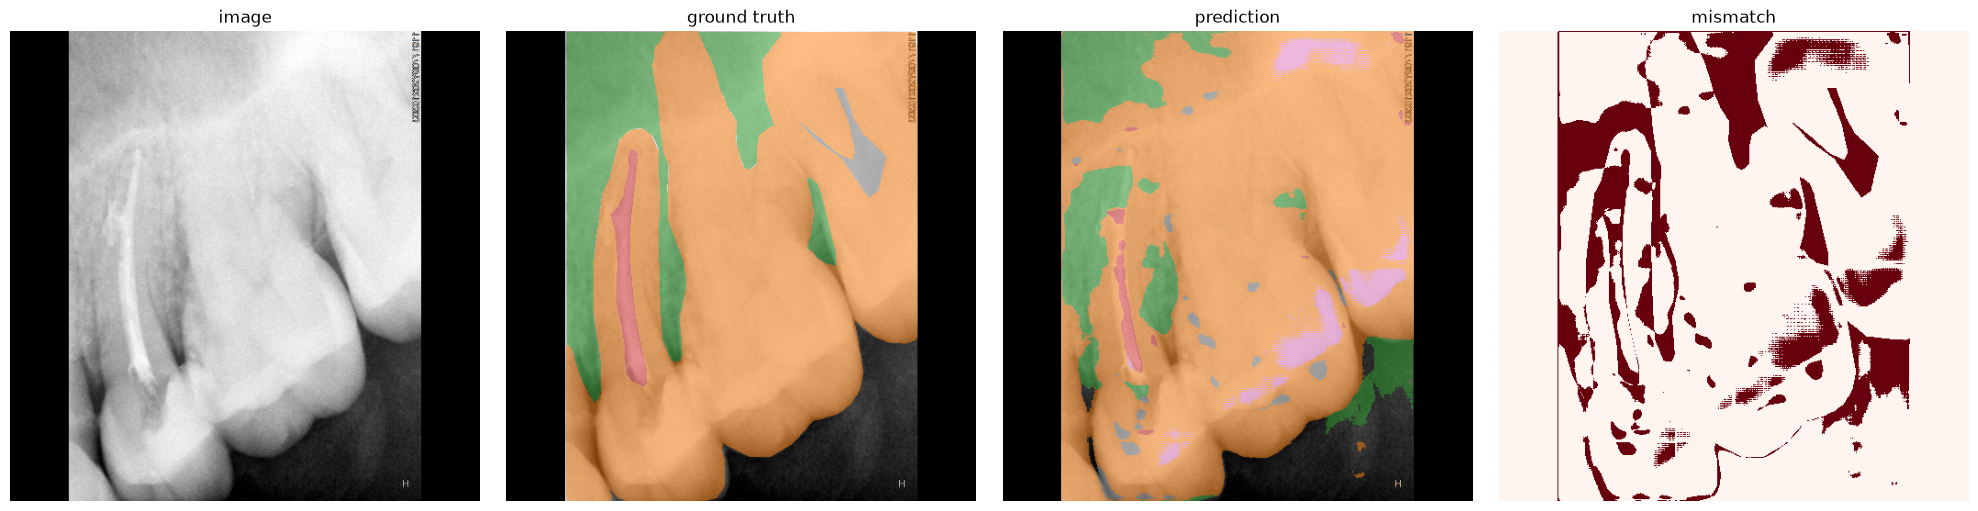

GT: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Pulp'] | PRED: ['Tooth', 'Alveolar Bone (AB)', 'Root Canal Filling (RCF)', 'Denture Crown (DC)', 'Dental Fillings (DF)', 'Pulp']


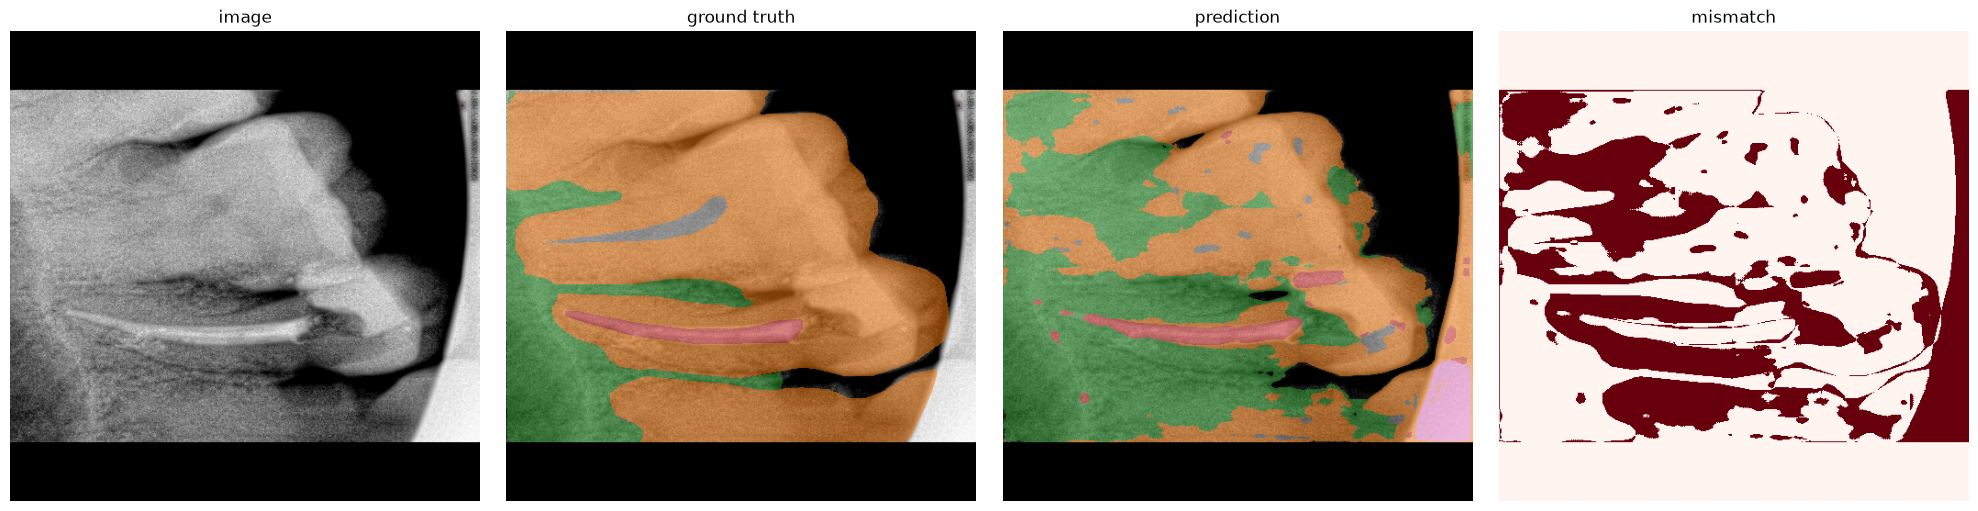

In [3]:
ds = Dataset(list_pairs(SPLIT, limit=N), eval_transforms)
dl = DataLoader(ds, batch_size=1, num_workers=0)

def masked(m):
    return np.ma.masked_where(m == 0, m)

with torch.no_grad():
    for batch in dl:
        x = batch['image'].to(device)
        gt = batch['label'][0, 0].numpy()
        with torch.autocast(device, enabled=device == 'cuda'):
            out = sliding_window_inference(x, (CROP, CROP), 2, model)
        pred = out[0].argmax(0).cpu().numpy()
        img = x[0].cpu().numpy().transpose(1, 2, 0)

        gt_cls = sorted(int(c) for c in np.unique(gt) if c)
        pr_cls = sorted(int(c) for c in np.unique(pred) if c)
        print('GT:', [names[c] for c in gt_cls], '| PRED:', [names[c] for c in pr_cls])

        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        ax[0].imshow(img); ax[0].set_title('image')
        ax[1].imshow(img); ax[1].imshow(masked(gt), cmap=cmap, vmin=0, vmax=NUM_CLASSES-1, alpha=0.5)
        ax[1].set_title('ground truth')
        ax[2].imshow(img); ax[2].imshow(masked(pred), cmap=cmap, vmin=0, vmax=NUM_CLASSES-1, alpha=0.5)
        ax[2].set_title('prediction')
        ax[3].imshow(gt != pred, cmap='Reds'); ax[3].set_title('mismatch')
        for a in ax: a.axis('off')
        plt.tight_layout(); plt.show()

## Per-class Dice on these samples

In [4]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete, Compose, EnsureType

post_pred = Compose([EnsureType(), AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)])
post_lbl = Compose([EnsureType(), AsDiscrete(to_onehot=NUM_CLASSES)])
dice = DiceMetric(include_background=False, reduction='none')

with torch.no_grad():
    for batch in dl:
        x, y = batch['image'].to(device), batch['label'].to(device)
        with torch.autocast(device, enabled=device == 'cuda'):
            out = sliding_window_inference(x, (CROP, CROP), 2, model)
        dice(y_pred=[post_pred(o) for o in out], y=[post_lbl(o) for o in y])

d = np.nanmean(dice.aggregate().cpu().numpy(), axis=0)
for k in range(1, NUM_CLASSES):
    print(f'{names[k]:<26} {d[k-1]:.4f}')
print(f'{"MEAN (fg)":<26} {np.nanmean(d):.4f}')

Tooth                      0.7754
Alveolar Bone (AB)         0.6714
Root Canal Filling (RCF)   0.6080
Denture Crown (DC)         nan
Implant (IM)               nan
Dental Fillings (DF)       0.0017
Pulp                       0.2930
Orthodontic Devices (OD)   nan
Apical Periodontitis (AP)  0.0000
MEAN (fg)                  0.3916


C:\Users\pierre bassily\AppData\Local\Temp\ipykernel_20328\3499183107.py:15: RuntimeWarning: Mean of empty slice
  d = np.nanmean(dice.aggregate().cpu().numpy(), axis=0)
